# Analyzing the weekday representation in language models

All experiment code is in this notebook, functions outside this notebook are only used for caching activations.

In [9]:
# Notebook setup
%cd /home/can/feature_zoo/
%load_ext autoreload
%autoreload 2

/home/can/feature_zoo
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
# Initialize Experiment config (defines dataset, model, sae)


from src.config import load_config

overrides_list = [
    "llm=gpt2",
    # "llm=llama3.1-8b-base", # Uncomment to switch models or select multiple models.
    # "llm=olmo3-32b-base",
]

In [12]:
from src.cache_llm import load_short_trajectory_acts
import torch as th
import numpy as np
import matplotlib.pyplot as plt
import einops
import time

def to_numpy(t: th.Tensor) -> np.ndarray:
    return t.detach().cpu().float().numpy()

def load_concept_labels(cfg):
    with open(f"data/texts/{cfg.filter.data}.txt") as f:
        lines = f.readlines()
    return lines

# Cache data for all models
model_data = {}  # {model_name: {"labels", "texts", "input_ids_BT", "llm_BCD"}}

for override in overrides_list:
    # Clear CUDA cache before loading new model
    th.cuda.empty_cache()
    
    cfg = load_config(overrides=[override])
    model_name = cfg.llm.name
    print(f"Loading {model_name}...")
    return_dict = load_short_trajectory_acts(cfg, force_recompute=False) # For now, leave force_recompute=True, I get buggy results for force recompute=False

    # Move to CPU immediately to free GPU memory
    if isinstance(return_dict["llm_BCD"], th.Tensor):
        llm_BWD = return_dict["llm_BCD"]
        llm_BCD = to_numpy(llm_BWD)
        input_ids_BT = return_dict["input_ids_BT"].cpu() if isinstance(return_dict["input_ids_BT"], th.Tensor) else return_dict["input_ids_BT"]
    
    model_data[model_name] = {
        "elements_B": return_dict["elements_B"],
        "labels_B": return_dict["labels_B"],
        "texts_B": return_dict["texts_N"],
        "input_ids_BT": input_ids_BT,
        "llm_BCD": llm_BCD,
    }
    
    del return_dict
    
    print(f"  {model_name} llm_BCD shape: {llm_BCD.shape}")
    

Loading gpt2...


KeyError: 'elements_B'

The dataset contains short webtext sentence templates that end with a weekday.
Example: The local mayor said an important statement last [WEEKDAY]

We extract representations at the final token of the [WEEKDAY]. Every template occurs 7 times in the dataset, once for each weekday.
Importantly, we minimize the template-related information by subtracting the mean per template.

In [4]:
for model_name in model_data:
    llm_BCD = model_data[model_name]["llm_BCD"]
    model_data[model_name]["llm_BCD"] = llm_BCD - np.mean(llm_BCD, axis=1, keepdims=True)

# SVD

In [ ]:
# Compute SVD for each model
model_svd = {}  # {model_name: {"U_BCD", "S_D", "Vh_DD", "rel_energy_D", "cumsum_rel_energy_D"}}

for model_name, data in model_data.items():
    llm_BCD = data["llm_BCD"]
    llm_BD = einops.rearrange(llm_BCD, "B C D -> (B C) D")
    U_BD, S_D, Vh_DD = np.linalg.svd(llm_BD, full_matrices=False)
    U_BCD = einops.rearrange(U_BD, "(B C) D -> B C D", C=cfg.data.num_elements)

    rel_energy_D = S_D**2 / (S_D**2).sum()
    cumsum_rel_energy_D = np.cumsum(rel_energy_D)

    model_svd[model_name] = {
        "U_BCD": U_BCD,
        "S_D": S_D,
        "Vh_DD": Vh_DD,
        "rel_energy_D": rel_energy_D,
        "cumsum_rel_energy_D": cumsum_rel_energy_D,
    }

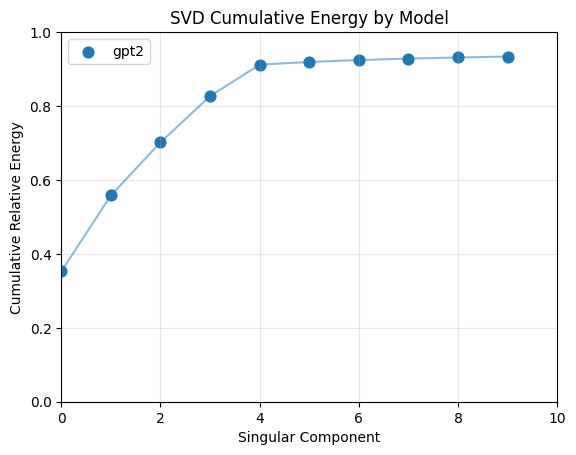

In [6]:
def plot_SVD_energy_multi(model_svd: dict):
    """Plot cumulative energy for all models on same axes."""
    colors = plt.cm.tab10(np.linspace(0, 1, len(model_svd)))

    for idx, (model_name, svd_data) in enumerate(model_svd.items()):
        cumsum_D = svd_data["cumsum_rel_energy_D"][:10]
        indices_D = np.arange(len(cumsum_D))
        plt.scatter(indices_D, cumsum_D,
                   c=[colors[idx]], marker='o',
                   label=model_name, s=60)
        plt.plot(indices_D, cumsum_D, c=colors[idx], alpha=0.5)

    plt.xlim(0, 10)
    plt.ylim(0, 1)
    plt.xlabel('Singular Component')
    plt.ylabel('Cumulative Relative Energy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title('SVD Cumulative Energy by Model')
    plt.show()

plot_SVD_energy_multi(model_svd)

IndexError: index 6 is out of bounds for axis 0 with size 6

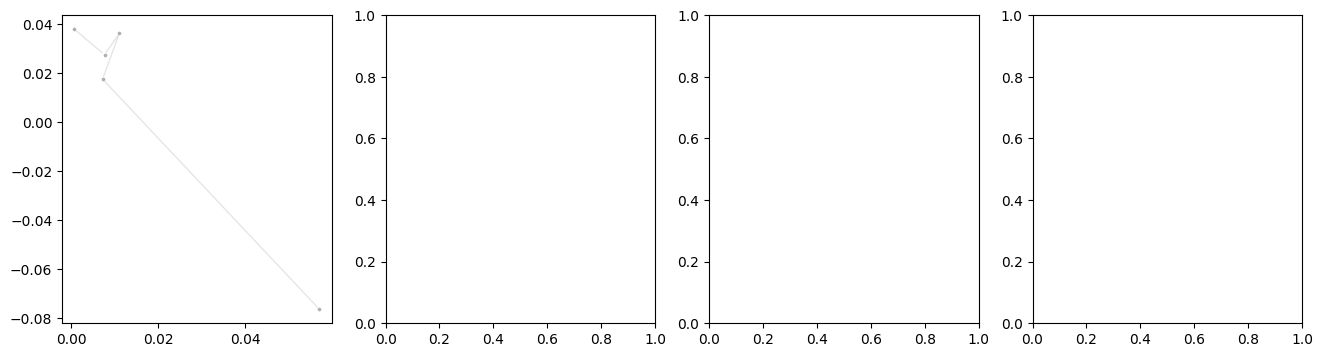

In [8]:
from typing import Callable, Dict, List

def plot_2d_projections_multi(
    model_data: dict,
    concept_labels: List[str],
    n_cols: int,
    suptitle: str,
    get_projection: Callable[[dict, int], tuple[np.ndarray, np.ndarray, str, str, str]],
    projection_kwargs: Dict = {},
    axlim: float | None = None,
    equal_aspect: bool = False,
    hide_ticks: bool = False,
    centroid_arrow_mode: str = "cyclic",
    centroid_arrow_size: float = 15,
    rotate_subplot: bool = False,
    num_plotted_trajectories: int | None = 20,
    radial_labels_offset: float | None = None,
    figsize: tuple | None = None,
):
    """
    Plot 2D projections of weekday trajectories for multiple models.

    Args:
        model_data: dict mapping model_name -> data dict (structure depends on get_projection)
        n_cols: number of subplot columns
        get_projection: callable(data_dict, col_idx) -> (proj_x_BC, proj_y_BC, xlabel, ylabel, title)
        suptitle: title for the entire figure
        axlim: fixed axis limit. If None, computed dynamically per subplot.
        equal_aspect: whether to set equal aspect ratio on subplots
        hide_ticks: whether to hide all axis ticks, tick labels, subplot titles, and figure title
        centroid_arrow_mode: "cyclic" (arrows between consecutive days), "mon_lr" (arrows from Monday to nearest neighbors), or "none"
        rotate_subplot: if True, rotate so Monday centroid is at top center, and append "(rotated)" to axis labels
        num_plotted_trajectories: the number of individual datapoints (connected grey dots) to plot per centroid. None -> plot all points
        radial_labels_offset: if not None, place labels radially outside centroids at this distance instead of using a legend
    """
    n_models = len(model_data)
    if figsize is None:
        figsize = (4 * n_cols, 4 * n_models)
    fig, axes = plt.subplots(n_models, n_cols, figsize=figsize)

    if n_models == 1:
        axes = axes.reshape(1, -1)

    colors = plt.cm.rainbow(np.linspace(0, 1, 7))

    for row, (model_name, data) in enumerate(model_data.items()):
        for col in range(n_cols):
            ax = axes[row, col]
            
            proj_x_BC, proj_y_BC, xlabel, ylabel, title = get_projection(data, col, **projection_kwargs)

            # Apply rotation if requested (rotate so Monday centroid is at top)
            if rotate_subplot:
                monday_x = proj_x_BC.mean(axis=0)[0]
                monday_y = proj_y_BC.mean(axis=0)[0]
                # Current angle of Monday from positive x-axis
                current_angle = np.arctan2(monday_y, monday_x)
                # Target angle is pi/2 (top = positive y-axis)
                # Rotation angle needed: pi/2 - current_angle
                rotation_angle = np.pi / 2 - current_angle
                cos_a, sin_a = np.cos(rotation_angle), np.sin(rotation_angle)
                # Apply rotation matrix: [cos -sin; sin cos]
                proj_x_BC_rot = proj_x_BC * cos_a - proj_y_BC * sin_a
                proj_y_BC_rot = proj_x_BC * sin_a + proj_y_BC * cos_a
                proj_x_BC, proj_y_BC = proj_x_BC_rot, proj_y_BC_rot
                xlabel = f"{xlabel} (rotated)"
                ylabel = f"{ylabel} (rotated)"

            # Determine axis limits
            if axlim is not None:
                current_axlim = axlim
            else:
                current_axlim = np.max(np.abs([proj_x_BC, proj_y_BC])) * 1.1

            # Plot individual trajectories (gray)
            for b in range(min(num_plotted_trajectories, proj_x_BC.shape[0])):
                x_coords_C = np.clip(proj_x_BC[b], -current_axlim, current_axlim)
                y_coords_C = np.clip(proj_y_BC[b], -current_axlim, current_axlim)
                for c in range(7):
                    next_c = (c + 1) % 7
                    ax.annotate('', xy=(x_coords_C[next_c], y_coords_C[next_c]),
                            xytext=(x_coords_C[c], y_coords_C[c]),
                            arrowprops=dict(arrowstyle='-', alpha=0.2, color='gray'),
                            annotation_clip=True)
                    ax.scatter(x_coords_C[c], y_coords_C[c], c='grey', s=3, alpha=0.5)

            # Plot mean trajectory (colored)
            mean_x_C = proj_x_BC.mean(axis=0)
            mean_y_C = proj_y_BC.mean(axis=0)
            for c in range(7):
                # Only add legend labels if using legend (not radial labels)
                label = concept_labels[c] if (col == n_cols - 1 and radial_labels_offset is None) else None
                ax.scatter(mean_x_C[c], mean_y_C[c], c=[colors[c]], s=150,
                        label=label, zorder=5, edgecolors='black')
                
                # Add radial labels if requested
                if radial_labels_offset is not None:
                    # Calculate unit vector from origin to centroid
                    dist = np.sqrt(mean_x_C[c]**2 + mean_y_C[c]**2)
                    if dist > 0:
                        unit_x = mean_x_C[c] / dist
                        unit_y = mean_y_C[c] / dist
                    else:
                        unit_x, unit_y = 1, 0  # fallback for centroid at origin
                    # Place label at centroid + offset along radial direction
                    label_x = mean_x_C[c] + radial_labels_offset * unit_x
                    label_y = mean_y_C[c] + radial_labels_offset * unit_y
                    ax.text(label_x, label_y, concept_labels[c], fontsize=12,
                            ha='center', va='center', fontweight='bold')

            # Draw centroid arrows based on mode
            if centroid_arrow_mode == "cyclic":
                for c in range(7):
                    next_c = (c + 1) % 7
                    ax.annotate('', xy=(mean_x_C[next_c], mean_y_C[next_c]),
                            xytext=(mean_x_C[c], mean_y_C[c]),
                            arrowprops=dict(arrowstyle='->', color='black', lw=2, mutation_scale=centroid_arrow_size),
                            annotation_clip=True)
            elif centroid_arrow_mode == "mon_lr":
                # Find two nearest neighbors to Monday (index 0)
                monday_pos_2 = np.array([mean_x_C[0], mean_y_C[0]])
                distances = []
                for c in range(1, 7):
                    dist = np.sqrt((mean_x_C[c] - monday_pos_2[0])**2 + (mean_y_C[c] - monday_pos_2[1])**2)
                    distances.append((dist, c))
                distances.sort()
                nearest_two = [distances[0][1], distances[1][1]]
                for neighbor_c in nearest_two:
                    ax.annotate('', xy=(mean_x_C[neighbor_c], mean_y_C[neighbor_c]),
                            xytext=(mean_x_C[0], mean_y_C[0]),
                            arrowprops=dict(arrowstyle='->', color='black', lw=2, mutation_scale=centroid_arrow_size),
                            annotation_clip=True)
            # mode "none": no arrows drawn

            ax.set_xlim((-current_axlim, current_axlim))
            ax.set_ylim((-current_axlim, current_axlim))
            
            if hide_ticks:
                ax.set_xticks([])
                ax.set_yticks([])
                for s in ax.spines.values():
                    s.set_visible(False)
            else:
                ax.set_xlabel(xlabel)
                if col == 0:
                    ax.set_ylabel(f'{model_name}\n\n{ylabel}')
                else:
                    ax.set_ylabel(ylabel)
                if row == 0:
                    ax.set_title(title)

            # Only show legend if not using radial labels
            if col == n_cols - 1 and radial_labels_offset is None:
                ax.legend(loc='upper left', fontsize=6)
            if equal_aspect:
                ax.set_aspect('equal')

    if not hide_ticks:
        plt.suptitle(suptitle, fontsize=14)
    plt.tight_layout()
    plt.show()


# Plot SVD eigendata
def svd_projection(data: dict, col: int, dim_pairs):
    """
    Get SVD dimension pair projection.
    
    dim_pairs: Pairs that should be plotted, eg. [(0, 1), (2, 3), (4, 5), (6, 7)]
    """
    dim1, dim2 = dim_pairs[col]
    U_BCD = data["U_BCD"]
    return (
        U_BCD[:, :, dim1],
        U_BCD[:, :, dim2],
        f'SVD dim {dim1}',
        f'SVD dim {dim2}',
        f'Dims {dim1}-{dim2}'
    )

plot_2d_projections_multi(
    model_svd,
    concept_labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
    n_cols=4, 
    get_projection=svd_projection,
    projection_kwargs=dict(dim_pairs=[(0, 1), (2, 3), (4, 5), (6, 7)]),
    suptitle="2D projections showing cyclic weekday structure", 
    axlim=0.08, 
    rotate_subplot=True
)

# Day Increment Operator / Transition Matrix

In [ ]:
S = 6 # Number of relevant top SVD components

In [ ]:
# Compute Increment operator for each model
model_increment = {}  # {model_name: {"A_SS", "eval_E", "evec_ES", "U_BCS", "planesX_ES", "planesY_ES", "positive_eval_idx_E"}}

for model_name, svd_data in model_svd.items():
    U_BCD = svd_data["U_BCD"]
    U_BCS = U_BCD[:, :, :S]
    
    batch_arange_B = np.arange(U_BCS.shape[0])
    concept_arange_C = np.arange(U_BCS.shape[1])
    concept_increment_C = np.concatenate([concept_arange_C[1:], [0]])
    
    X_next_BCS = U_BCS[batch_arange_B[:, None], concept_increment_C[None, :]]
    
    X_current_BS = einops.rearrange(U_BCS, "B C S -> (B C) S")
    X_next_BS = einops.rearrange(X_next_BCS, "B C S -> (B C) S")
    U_inv_DB = einops.rearrange(U_BCD, "B C D -> D (B C)")
    X_inv_current_SB = U_inv_DB[:S]
    
    # A_SS @ X_current_BS.T = X_next_BS.T
    A_SS = X_next_BS.T @ X_inv_current_SB.T
    eval_E, evec_SE = np.linalg.eig(A_SS)
    evec_ES = evec_SE.T
    
    # Get indices for positive imaginary eigenvalues (conjugate pairs)
    positive_eval_idx_E = [i for i in range(len(eval_E)) if np.imag(eval_E[i]) > 0]
    planesX_ES = np.real(evec_ES[positive_eval_idx_E])
    planesY_ES = np.imag(evec_ES[positive_eval_idx_E])
    
    model_increment[model_name] = {
        "A_SS": A_SS,
        "eval_E": eval_E,
        "evec_ES": evec_ES,
        "U_BCS": U_BCS,
        "planesX_ES": planesX_ES,
        "planesY_ES": planesY_ES,
        "positive_eval_idx_E": positive_eval_idx_E,
    }
    
    print(f"{model_name}: eigenvalues = {eval_E}")

In [ ]:
def plot_complex_ev_multi(model_increment: dict, axlim=1.4) -> None:
    """Plot eigenvalues for all models."""
    n_models = len(model_increment)
    fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))
    
    if n_models == 1:
        axes = [axes]
    
    for idx, (model_name, inc_data) in enumerate(model_increment.items()):
        ax = axes[idx]
        evals = inc_data["eval_E"]
        
        ax.axhline(0, color='gray', linewidth=0.5, alpha=0.7)
        ax.axvline(0, color='gray', linewidth=0.5, alpha=0.7)
        circle = plt.Circle((0, 0), 1, color='gray', fill=False, linewidth=0.5, alpha=0.7)
        ax.add_patch(circle)
        
        ax.scatter(np.real(evals), np.imag(evals), s=60)
        
        ax.set_xlim(-axlim, axlim)
        ax.set_ylim(-axlim, axlim)
        ax.set_xlabel("Real(EV)")
        ax.set_ylabel("Imag(EV)")
        ax.set_title(model_name)
        ax.set_aspect('equal')
    
    plt.suptitle('Increment Operator Eigenvalues', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_complex_ev_multi(model_increment)

In [ ]:
# Plot eigenplane projections using the generalized function
def eigenplane_projection(data: dict, col: int):
    """Get eigenplane projection."""
    U_BCS = data["U_BCS"]
    planesX_ES = data["planesX_ES"]
    planesY_ES = data["planesY_ES"]
    return (
        U_BCS @ planesX_ES[col],
        U_BCS @ planesY_ES[col],
        f'Re(evec {col})',
        f'Im(evec {col})',
        f'Eigenplane {col}'
    )

plot_2d_projections_multi(
    model_increment,
    n_cols=3, 
    get_projection=eigenplane_projection,
    suptitle="Projections onto Increment Operator Eigenplanes", 
    equal_aspect=True,
    hide_ticks=True,
    centroid_arrow_mode="mon_lr",
    rotate_subplot=True,
    radial_labels_offset=0.009,
    figsize=(12, 4),
    axlim=0.05,
    num_plotted_trajectories=50,
    centroid_arrow_size=25
)

In [ ]:
# Eigenvectors are not necessarily orthogonal. The images look very different, so this strongly suggests they are. Nevertheless, let's doublecheck they are orthogonal.
# The right singular vectors of the representation data llm_BD = U S Vh map.

Vh_DD = model_svd["gpt2"]["Vh_DD"]
planes_2ES = np.concat((model_increment["gpt2"]["planesX_ES"], model_increment["gpt2"]["planesY_ES"]), axis=0)
planes_2ED = planes_2ES @ Vh_DD[:6, :]
planes_2ED = planes_2ED / np.linalg.norm(planes_2ED, axis=-1, keepdims=True)

plt.imshow(planes_2ED @ planes_2ED.T)
plt.colorbar()

Next, it would be interesting to find which weights in GPT-2 implement the weekday-increment operator.